In [32]:
import pandas as pd
import numpy as np

In [33]:
train2 = pd.read_csv("../train2/remaining_train2_eval_04_27.csv", index_col=False)
train2['display_name'] = train2.display_name.str.replace("covid", "covid19_twitter").str.replace("ukr_rus", "ukr_rus_twitter")

datasets = [     'election2020',   'covid_political', 'ukr_rus_suspended',
   'ukr_rus_twitter',           'midterm',   'covid19_twitter']
ds_pat = "|".join(datasets)
task_pat = "nm|lp|pl"
pat = f'_({ds_pat})_({task_pat})_to_({ds_pat})_({task_pat})_'
train2[['train1_dataset', 'train1_task', 'train2_dataset', 'train2_task']] = train2.display_name.str.extract(pat)


In [34]:
df = train2.copy()

df['train_id'] = (
    df.train1_dataset + '+' +
    df.train1_task + '>' +
    df.train2_dataset + '+' +
    df.train2_task
)

# mat_df = df.groupby([''])
df['eval_id_'] = df.eval_id.str.replace('\(\d+\)', '', regex=True)

mat_train2 = df[df.n_shots.eq(3)]

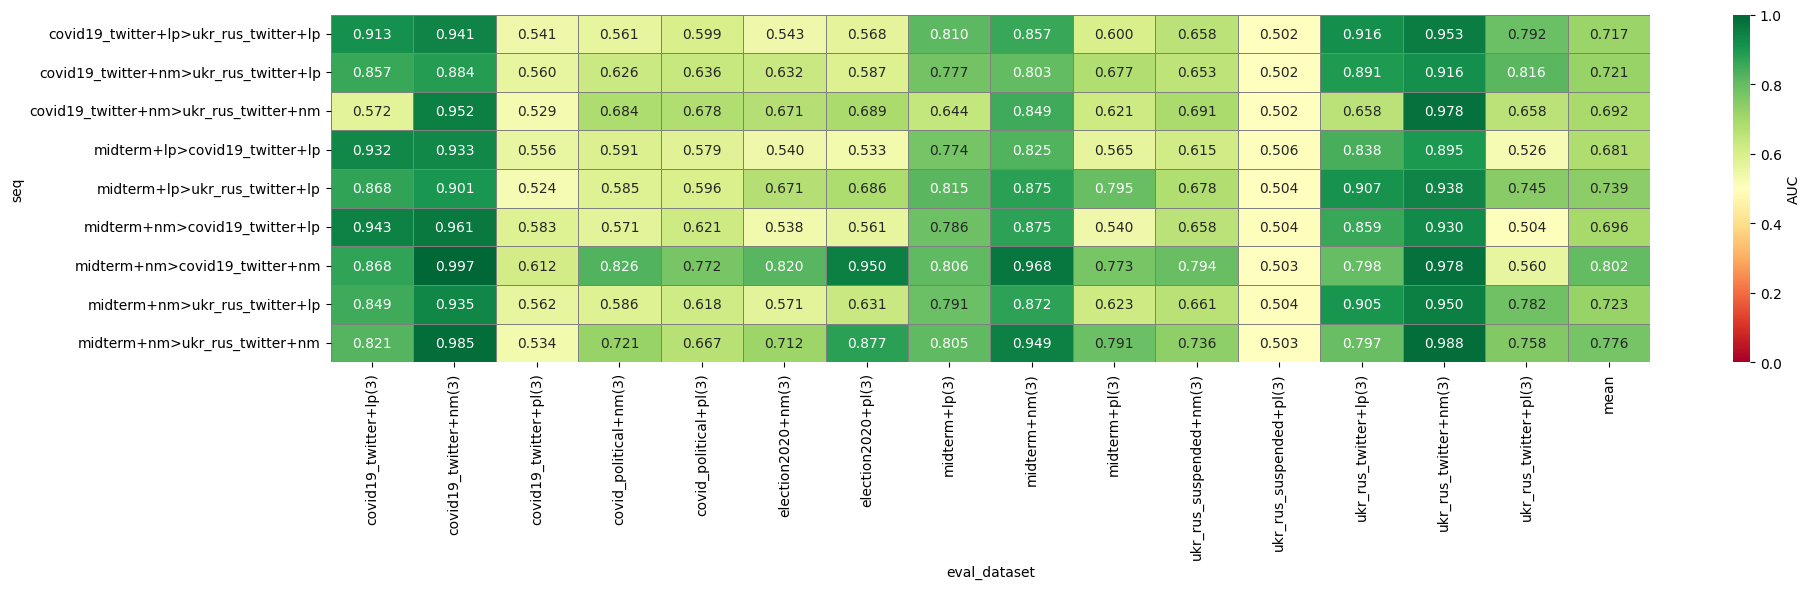

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# pivot to matrix: rows=seq, cols=eval_dataset
mat = mat_train2.pivot_table(
    index="train_id",
    columns="eval_id",
    values="auc",
    # aggfunc="mean"   # or max/min depending on meaning
)

mat["mean"] = mat.mean(axis=1)

# plot
plt.figure(figsize=(20,6))
sns.heatmap(
    mat,
    cmap="RdYlGn",
    vmin=0, vmax=1,
    annot=True,        # show values
    fmt=".3f",         # 3 decimal places
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "AUC"}
)

plt.ylabel("seq")
plt.xlabel("eval_dataset")
plt.tight_layout()
plt.show()

In [36]:
train2['train1_tuple'] = train2.train1_dataset + "+" + train2.train1_task
train2['train2_tuple'] = train2.train2_dataset + "+" + train2.train2_task

train2['train_id'] = train2.train1_tuple + ">" + train2.train2_tuple

In [37]:
df['train_id_'] = df['train_id'].str.replace("\(\d+\)", '', regex=True)
df['eval_id_'] = df['eval_id'].str.replace("\(\d+\)", '', regex=True)

train2['train_id_'] = train2['train_id'].str.replace("\(\d+\)", '', regex=True)
train2['eval_id_'] = train2['eval_id'].str.replace("\(\d+\)", '', regex=True)

In [39]:
mat = pd.concat([
    train1, 
    train2, 
    # covid_df
    ])
# mat.sort_values('shots', ascending=False).drop_duplicates('seq_').shape
mat[mat.shots.eq(3)]

,run_id,display_name,state,dataset,task_name,prefix,pretrained_model_run,n_shots,n_way,n_query,...,auc_rounded,seq_,eval_id_,train_id_,train1_dataset,train1_task,train2_dataset,train2_task,train1_tuple,train2_tuple
198,z99z7b3o,eval_midterm_nm_to_ukr_rus_suspended_pl_3shot_...,finished,ukr_rus_suspended,pl,eval_midterm_nm_to_ukr_rus_suspended_pl_3shot,state/train1_midterm_nm_1p5m_13_04_2026_18_03_...,3.0,2.0,12.0,...,0.502543,midterm+nm|ukr_rus_suspended+pl,ukr_rus_suspended+pl,midterm+nm,midterm,nm,NaN,NaN,NaN,NaN
199,60rprpso,eval_covid19_twitter_nm_to_election2020_pl_3sh...,finished,election2020,pl,eval_covid19_twitter_nm_to_election2020_pl_3shot,state/train1_covid19_twitter_nm_1p5m_13_04_202...,3.0,2.0,12.0,...,0.826238,covid19_twitter+nm|election2020+pl,election2020+pl,covid19_twitter+nm,covid19_twitter,nm,NaN,NaN,NaN,NaN
200,q2ar8vh7,eval_midterm_nm_to_ukr_rus_suspended_nm_3shot_...,finished,ukr_rus_suspended,nm,eval_midterm_nm_to_ukr_rus_suspended_nm_3shot,state/train1_midterm_nm_1p5m_13_04_2026_18_03_...,3.0,3.0,12.0,...,0.712647,midterm+nm|ukr_rus_suspended+nm,ukr_rus_suspended+nm,midterm+nm,midterm,nm,NaN,NaN,NaN,NaN
201,62049chm,eval_covid19_twitter_nm_to_election2020_nm_3sh...,finished,election2020,nm,eval_covid19_twitter_nm_to_election2020_nm_3shot,state/train1_covid19_twitter_nm_1p5m_13_04_202...,3.0,3.0,12.0,...,0.735601,covid19_twitter+nm|election2020+nm,election2020+nm,covid19_twitter+nm,covid19_twitter,nm,NaN,NaN,NaN,NaN
202,j1117y6d,eval_ukr_rus_twitter_nm_to_covid_political_pl_...,finished,covid_political,pl,eval_ukr_rus_twitter_nm_to_covid_political_pl_...,state/train1_ukr_rus_twitter_nm_1p5m_13_04_202...,3.0,2.0,12.0,...,0.624670,ukr_rus_twitter+nm|covid_political+pl,covid_political+pl,ukr_rus_twitter+nm,ukr_rus_twitter,nm,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
251,xzpg2blb,eval_exp1_midterm_nm_to_covid19_twitter_nm_to_...,finished,ukr_rus_suspended,pl,eval_exp1_midterm_nm_to_covid_nm_to_ukr_rus_su...,/scratch1/singhama/data/experiments/train2_mid...,3.0,2.0,12.0,...,NaN,NaN,ukr_rus_suspended+pl,midterm+nm>covid19_twitter+nm,midterm,nm,covid19_twitter,nm,midterm+nm,covid19_twitter+nm
253,ds2afmvv,eval_exp1_midterm_nm_to_covid19_twitter_nm_to_...,finished,midterm,nm,eval_exp1_midterm_nm_to_covid_nm_to_midterm_nm...,/scratch1/singhama/data/experiments/train2_mid...,3.0,3.0,12.0,...,NaN,NaN,midterm+nm,midterm+nm>covid19_twitter+nm,midterm,nm,covid19_twitter,nm,midterm+nm,covid19_twitter+nm
254,b8g7ac05,eval_exp1_midterm_nm_to_covid19_twitter_nm_to_...,finished,covid_political,nm,eval_exp1_midterm_nm_to_covid_nm_to_covid_poli...,/scratch1/singhama/data/experiments/train2_mid...,3.0,3.0,12.0,...,NaN,NaN,covid_political+nm,midterm+nm>covid19_twitter+nm,midterm,nm,covid19_twitter,nm,midterm+nm,covid19_twitter+nm
256,87yqlh1j,eval_exp1_midterm_nm_to_covid19_twitter_nm_to_...,finished,covid19_twitter,nm,eval_exp1_midterm_nm_to_covid_nm_to_covid19_tw...,/scratch1/singhama/data/experiments/train2_mid...,3.0,3.0,12.0,...,NaN,NaN,covid19_twitter+nm,midterm+nm>covid19_twitter+nm,midterm,nm,covid19_twitter,nm,midterm+nm,covid19_twitter+nm


In [576]:
covid_df = covid_df[covid_df.shots.eq(3)]

In [ ]:
import numpy as np
import pandas as pd
from sympy import limit
import wandb


def to_pandas(runs, LIMIT=10):
   
    rows = []
    for run in runs[:LIMIT]:
        attrs = getattr(run, "_attrs", {}) or {}
        params = ((attrs.get("config") or {}).get("params") or {})
        summary = attrs.get("summaryMetrics") or {}

        rows.append({
            "run_id": attrs.get("name"),
            "display_name": attrs.get("displayName"),
            "state": attrs.get("state"),
            "dataset": params.get("dataset"),
            "task_name": params.get("task_name"),
            "prefix": params.get("prefix"),
            "pretrained_model_run": params.get("pretrained_model_run"),
            "n_shots": params.get("n_shots"),
            "n_way": params.get("n_way"),
            "n_query": params.get("n_query"),
            "zero_shot": params.get("zero_shot"),
            "test_accuracy": summary.get("test_accuracy"),
            "train_accuracy": summary.get("train_accuracy"),
            "test_f1": summary.get("test_f1"),
            "test_roc_auc": summary.get("test_roc_auc"),
            "created_at": attrs.get("createdAt"),
            'steps': attrs['historyKeys']['keys'].get('_step', {}).get('typeCounts', [{}])[0].get('count', np.nan),
            'tags': attrs.get("tags", []),
            'input_dim': params.get("input_dim"),
            'feature_subset': params.get('feature_subset', params.get('midterm_feature_subset')),
            'eval_only': params.get("eval_only"),
            'graph': params.get('root', 'nan') + '/' + params.get('graph_filename', 'nan')
        })
    df = pd.DataFrame(rows)
    df["task_name"] = df["task_name"].map({
        "neighbor_matching": "nm",
        "temporal_link_prediction": "lp",
        "classification": "pl",
    })
    df['created_at'] = pd.to_datetime(df['created_at'])
    df["shot_label"] = df.apply(lambda r: 0 if bool(r.get("zero_shot", False)) else r["n_shots"], axis=1)
    # df['is_eval'] = df['display_name'].str.contains(r"eval")
    # plot_df = df[df["eval1_task"].isin(EVAL_TASKS) & df["train1_task"].eq("nm")].copy()
    df['eval1_dataset'] = df['dataset']
    df['trained_on_display_name'] = df.pretrained_model_run.str.findall("(.+)/(.+)/((checkpoint/(.+)\.ckpt)|state_dict)$").str[0].str[1]
    df['month/day'] = df['created_at'].dt.month.astype(str) + '/' + df['created_at'].dt.day.astype(str)
    df = df.sort_values('created_at', ascending=False)
    mask = df['trained_on_display_name'].isin(df['display_name'])
    existing_trained_on_display_names = df.trained_on_display_name[mask]
    df__ = df.copy()

    df['shots'] = pd.to_numeric(df.n_shots.fillna(-1)).astype(int)

    df = df[df.dataset.isin(['midterm', 'ukr_rus_twitter', 'covid19_twitter', 'covid_political', 'ukr_rus_suspended', 'election2020'])]
    df = df[df.pretrained_model_run.notna()]
    df = df[~df.display_name.str.contains('train3')]
    df = df[~df.display_name.str.contains('eval_exp')]

    df["train_tuples"] = None  # or use pd.Series(dtype=object)
    df["run_list"] = None  # or use pd.Series(dtype=object)

    for i, row in list(df.iterrows()):
        train_list = []
        run_list = []
        row_ = row.copy()
        # print(row_.display_name)

        while pd.notna(row_.trained_on_display_name):
            # print("->", row_.trained_on_display_name)
            matches = df[df.display_name.eq(row_.trained_on_display_name)]
            if len(matches) != 1:
                print('warn:', row_.trained_on_display_name, )
                break
            row_ = matches.iloc[0]
            train_list.append((row_["dataset"], row_["task_name"], row_.get('shots', -1)))
            run_list.append(row_.run_id)

        # print('\t', train_list)
        df.at[i, "train_tuples"] = train_list
        df.at[i, "run_list"] = run_list


    # x = df.train_idx.explode().dropna().groupby(level=0).agg(list)
    # df['train_idx'] = np.nan
    # df['train_idx'] = x
    df = df[~df.display_name.str.contains('train\d*_')]

    df['train_id'] = df.train_tuples.apply(lambda x: [f'{d}+{t}({s})' for (d,t,s) in x]).apply('>'.join).replace({'':np.nan})
    df['eval_only'] = df['eval_only'].fillna(False)
    df.loc[df.eval_only, 'eval_dataset'] = df['dataset']
    df.loc[df.eval_only, 'eval_task'] = df['task_name']
    df.loc[df.eval_only, 'eval_id'] = df.eval_dataset + "+" + df.eval_task + "(" + df.shots.astype(str) + ")"
    df.loc[df.eval_only, 'run_idx'] = df.run_list.apply('>'.join).replace('', 'nan') + "|" + df.eval_id
    df['seq'] = df.train_id + "|" + df.eval_id

    df['auc'] = df.test_roc_auc
    df['f1'] = df.test_f1
    df = df[df.created_at.gt('03-01-2026')]
    # df = df.drop_duplicates(['seq', ''])
    df = df[df.feature_subset.eq('emb_only')]
    df = df[df.display_name.str[:10].isin(['trained_on', 'eval_covid', 'eval_midte', 'eval_ukr_r', 'eval_nm_on', 'eval_pl_on', 'eval_lp_on'])]

    graphs = ["/scratch1/eibl/data/covid_political/graphs/retweet_graph.pt",
    "/scratch1/eibl/data/election2020/graphs/retweet_graph.pt",
    "/scratch1/eibl/data/ukr_rus_suspended/graphs/retweet_graph.pt",
    "/scratch1/eibl/data/covid19_twitter/graphs/retweet_graph_1p5m_hf03_labeled.pt",
    "/scratch1/eibl/data/ukr_rus_twitter/graphs/retweet_graph_1p5m_hf03_political_labels.pt",
    "/scratch1/eibl/data/midterm/graphs/retweet_graph_1p5m.pt",]

    df = df[df.graph.isin(graphs)]

    df = df.dropna(subset=['auc'])

    # df.to_csv('./train1/train1.csv', index=False)
    
    return df



LIMIT = 120

api = wandb.Api(
    api_key="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",
    timeout=60
)

# 1. Get last 10 runs (sorted by creation time descending)
runs = api.runs(
    "eibl-usc/graph-clip",
    filters={
        # "display_name": {"$regex": "trained_on_.._eval_on_.._..?_shot_.+"},
        # "config.dataset": "ukr_rus_twitter",
        # "config.task_name": "neighbor_matching",
    },
    order="-created_at",
    per_page=LIMIT,
    # limit to 10:
    lazy=False
)

# covid_df_ = to_pandas(runs, LIMIT)

In [635]:
covid_df = covid_df_.copy()
covid_df = covid_df[covid_df.display_name.str.startswith('eval_covid_political')]
covid_df['shots'] = pd.to_numeric(df.shots).astype(int)
covid_df[['train1_dataset', 'train1_task', 'eval_dataset', 'eval_task', 'shots']] = covid_df.display_name.str.extract('eval_(.+)_(nm|pl|lp)_to_(.+)_(nm|pl|lp)_(\d+)shot')
covid_df['train_id'] = covid_df.train1_dataset + "+" + covid_df.train1_task
covid_df['eval_id'] = covid_df.eval_dataset + "+" + covid_df.eval_task + '(' + covid_df.shots + ')'
covid_df['train_id_'] = covid_df.train_id.str.replace("\(\d+\)", "", regex=True)
covid_df['eval_id_'] = covid_df.eval_id.str.replace("\(\d+\)", "", regex=True)
covid_df['auc'] = covid_df.test_roc_auc

In [53]:
train1 = pd.read_csv('../train1/train1.csv', index_col=None)
train1['seq_'] = train1.seq.str.replace("\(\d+\)", "", regex=True)
train1['eval_id_'] = train1.eval_id.str.replace("\(\d+\)", "", regex=True)
train1['train_id_'] = train1.train_id.str.replace("\(\d+\)", "", regex=True)
# mat_train1 = train1.sort_values('auc', ascending=False).drop_duplicates(subset=['seq_'])[['train_id', 'eval_id_', 'auc']]
datasets = [     'election2020',   'covid_political', 'ukr_rus_suspended',
   'ukr_rus_twitter',           'midterm',   'covid19_twitter']
ds_pat = "|".join(datasets)
task_pat = "nm|lp|pl"
pat = f'eval_({ds_pat})_({task_pat})_to_({ds_pat})_({task_pat})_\d+shot'
train1[['train1_dataset', 'train1_task', 'eval_dataset', 'eval_task']] = train1.display_name.str.extract(pat)
mat_train1 = train1[train1.n_shots.eq(3)]

tdf = pd.concat([mat_train1, mat_train2])
tdf = tdf[tdf.shots.isin([3])]

tdf['train_id_'] = tdf.train_id.str.replace('\(\d+\)', '', regex=True)
tdf['eval_id_'] = tdf['eval_id'].str.replace('\(\d+\)', '', regex=True)
tdf['seq_id'] = tdf['train_id_'] + "|" + tdf['eval_id_']

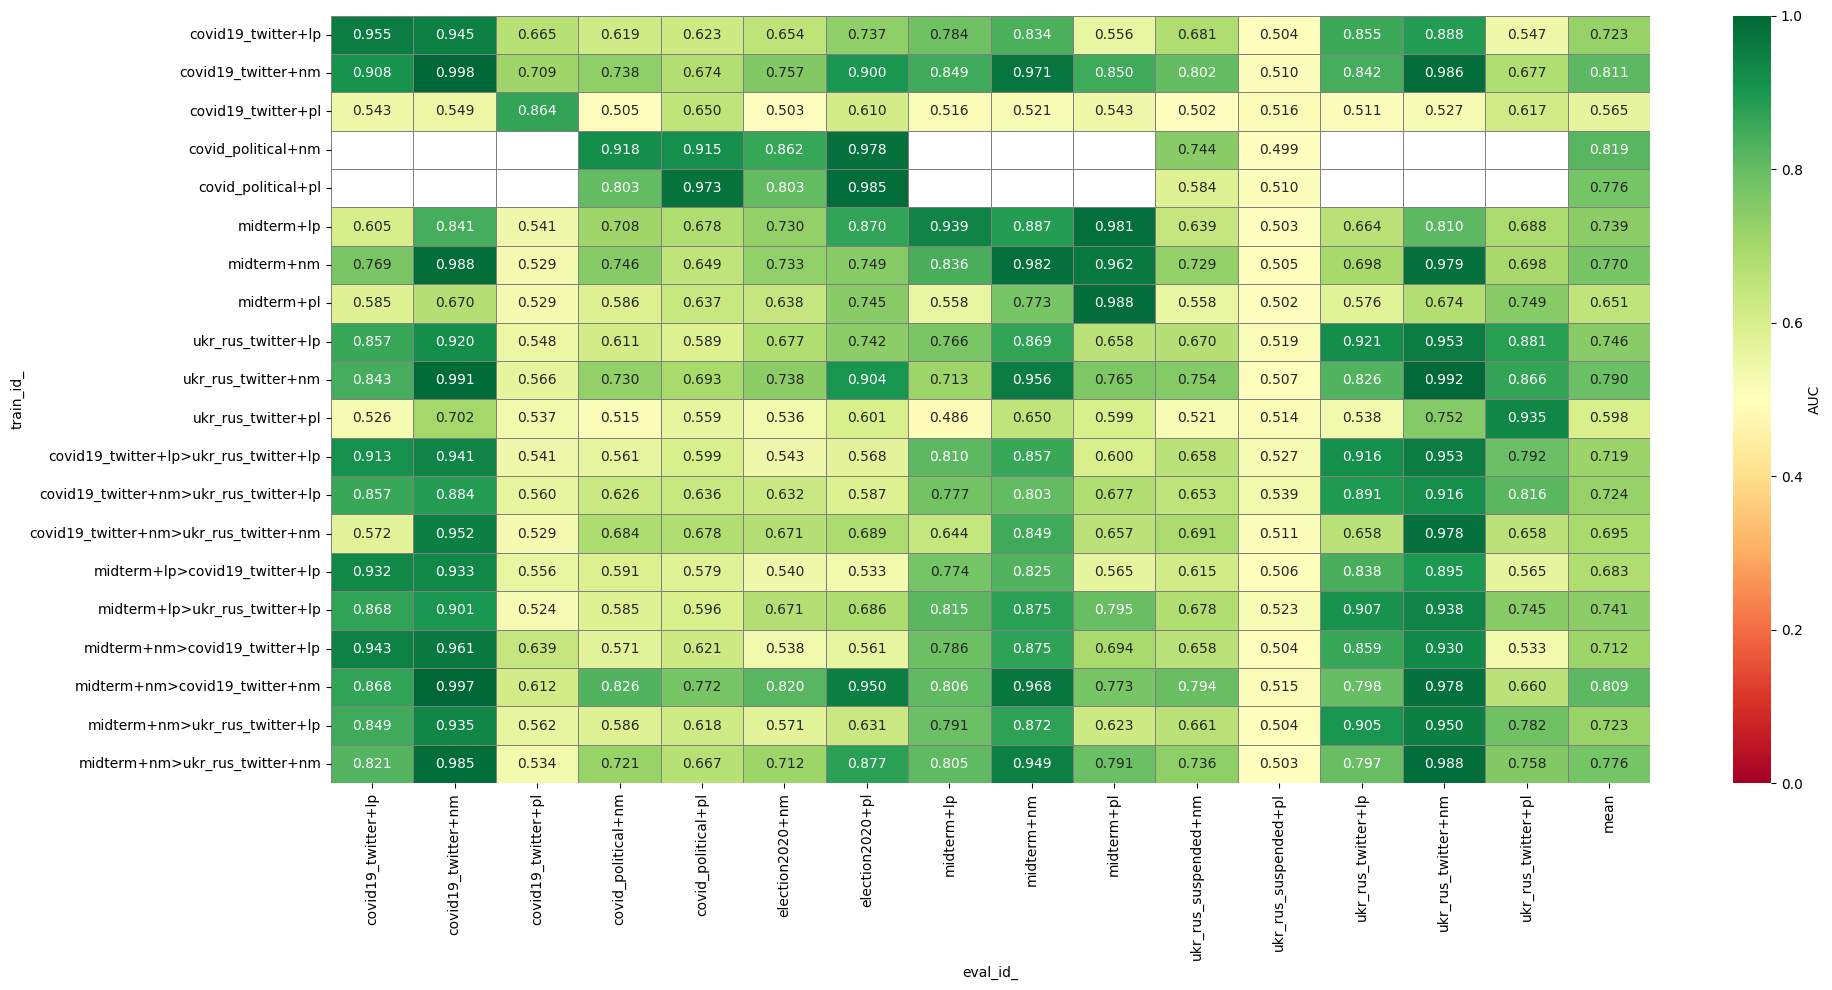

In [54]:
# long[['control_id', 'treatment_id', 'delta']]

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

metric = 'auc'

# pivot to matrix: rows=seq, cols=eval_dataset
mat = pd.concat([
    train1,
    train2, 
    # covid_df
    ])
mat = mat.sort_values(metric, ascending=False).drop_duplicates(['train_id_', 'eval_id_'])
mat['exp_name'] = mat.train_id_.str.contains('>', regex=False).map({True: 'train1', False: 'train2'})
mat = mat.sort_values(by=['exp_name'])
mat = mat.pivot_table(
    index="train_id_",
    columns="eval_id_",
    values=metric,
    # aggfunc="mean"   # or max/min depending on meaning
)
mat['exp_name'] = pd.Series(mat.index.str.contains('>', regex=False)).map({True: 'train2', False: 'train1'}).values
mat = mat.sort_values('exp_name').drop(columns='exp_name')
mat['mean'] = mat.mean(axis=1)

# plot
plt.figure(figsize=(20,10))
sns.heatmap(
    mat,
    cmap="RdYlGn",
    vmin=0, vmax=1,
    annot=True,        # show values
    fmt=".3f",         # 3 decimal places
    linewidths=0.5,
    linecolor="gray",
    cbar_kws={"label": "AUC"}
)

# plt.ylabel("seq")
# plt.xlabel("eval_dataset")
plt.tight_layout()
plt.show()

In [85]:
datasets = tdf.train1_dataset.unique()
tasks = tdf.train1_task.unique()

def seq_auc(seq_id):
    vals = tdf.loc[tdf.seq_id.eq(seq_id), "test_roc_auc"]
    return vals.mean() if len(vals) else None

def regime(Di, Tj, D, T):
    if D == Di and T == Tj:
        return "DiTj"
    if D != Di and T == Tj:
        return "DnTj"
    if D == Di and T != Tj:
        return "DiTn"
    return "DnTn"

rows = []
for Di in datasets:
    for Tj in tasks:
        DiTj = f"{Di}+{Tj}"
        for Dn in datasets:
            for Tn in tasks:
                Y = f"{Dn}+{Tn}"
                eval_regime = regime(Di, Tj, Dn, Tn)

                control_id = f"{DiTj}|{Y}"
                control_auc = seq_auc(control_id)
                if control_auc is None:
                    continue

                rows.append({
                    "treatment_type": "control (DiTj)",
                    "eval_regime": eval_regime,
                    "control_id": control_id,
                    "treatment_id": control_id,
                    "control_auc": control_auc,
                    "treatment_auc": control_auc,
                    "delta": 0.0,
                })

                for Dk in datasets:
                    if Dk == Di:
                        continue
                    DkTj = f"{Dk}+{Tj}"
                    for tid in [f"{DiTj}>{DkTj}|{Y}", f"{DkTj}>{DiTj}|{Y}"]:
                        auc = seq_auc(tid)
                        if auc is not None:
                            rows.append({
                                "treatment_type": "+dataset (DiTj+DkTj)",
                                "eval_regime": eval_regime,
                                "control_id": control_id,
                                "treatment_id": tid,
                                "control_auc": control_auc,
                                "treatment_auc": auc,
                                "delta": auc - control_auc,
                            })

                for Tk in tasks:
                    if Tk == Tj:
                        continue
                    DiTk = f"{Di}+{Tk}"
                    for tid in [f"{DiTj}>{DiTk}|{Y}", f"{DiTk}>{DiTj}|{Y}"]:
                        auc = seq_auc(tid)
                        if auc is not None:
                            rows.append({
                                "treatment_type": "+task (DiTj+DiTk)",
                                "eval_regime": eval_regime,
                                "control_id": control_id,
                                "treatment_id": tid,
                                "control_auc": control_auc,
                                "treatment_auc": auc,
                                "delta": auc - control_auc,
                            })

                for Dk in datasets:
                    if Dk in (Di, Dn):
                        continue
                    for Tl in tasks:
                        if Tl in (Tj, Tn):
                            continue
                        DkTl = f"{Dk}+{Tl}"
                        for tid in [f"{DiTj}>{DkTl}|{Y}", f"{DkTl}>{DiTj}|{Y}"]:
                            auc = seq_auc(tid)
                            if auc is not None:
                                rows.append({
                                    "treatment_type": "+dataset, +task (DiTj+DkTl)",
                                    "eval_regime": eval_regime,
                                    "control_id": control_id,
                                    "treatment_id": tid,
                                    "control_auc": control_auc,
                                    "treatment_auc": auc,
                                    "delta": auc - control_auc,
                                })


long = pd.DataFrame(rows)
long

,treatment_type,eval_regime,control_id,treatment_id,control_auc,treatment_auc,delta
0,control (DiTj),DiTj,midterm+nm|midterm+nm,midterm+nm|midterm+nm,0.980944,0.980944,0.000000
1,+dataset (DiTj+DkTj),DiTj,midterm+nm|midterm+nm,midterm+nm>covid19_twitter+nm|midterm+nm,0.980944,0.967897,-0.013047
2,+dataset (DiTj+DkTj),DiTj,midterm+nm|midterm+nm,midterm+nm>ukr_rus_twitter+nm|midterm+nm,0.980944,0.948678,-0.032266
3,"+dataset, +task (DiTj+DkTl)",DiTj,midterm+nm|midterm+nm,midterm+nm>covid19_twitter+lp|midterm+nm,0.980944,0.874745,-0.106199
4,"+dataset, +task (DiTj+DkTl)",DiTj,midterm+nm|midterm+nm,midterm+nm>ukr_rus_twitter+lp|midterm+nm,0.980944,0.872124,-0.108820
...,...,...,...,...,...,...,...
208,control (DiTj),DiTj,ukr_rus_twitter+lp|ukr_rus_twitter+lp,ukr_rus_twitter+lp|ukr_rus_twitter+lp,0.921011,0.921011,0.000000
209,+dataset (DiTj+DkTj),DiTj,ukr_rus_twitter+lp|ukr_rus_twitter+lp,midterm+lp>ukr_rus_twitter+lp|ukr_rus_twitter+lp,0.921011,0.907367,-0.013644
210,+dataset (DiTj+DkTj),DiTj,ukr_rus_twitter+lp|ukr_rus_twitter+lp,covid19_twitter+lp>ukr_rus_twitter+lp|ukr_rus_...,0.921011,0.916360,-0.004651
211,"+dataset, +task (DiTj+DkTl)",DiTj,ukr_rus_twitter+lp|ukr_rus_twitter+lp,midterm+nm>ukr_rus_twitter+lp|ukr_rus_twitter+lp,0.921011,0.905499,-0.015513


In [118]:
long[['control_id', 'treatment_id']]

,control_id,treatment_id
0,midterm+nm|midterm+nm,midterm+nm|midterm+nm
1,midterm+nm|midterm+nm,midterm+nm>covid19_twitter+nm|midterm+nm
2,midterm+nm|midterm+nm,midterm+nm>ukr_rus_twitter+nm|midterm+nm
3,midterm+nm|midterm+nm,midterm+nm>covid19_twitter+lp|midterm+nm
4,midterm+nm|midterm+nm,midterm+nm>ukr_rus_twitter+lp|midterm+nm
...,...,...
208,ukr_rus_twitter+lp|ukr_rus_twitter+lp,ukr_rus_twitter+lp|ukr_rus_twitter+lp
209,ukr_rus_twitter+lp|ukr_rus_twitter+lp,midterm+lp>ukr_rus_twitter+lp|ukr_rus_twitter+lp
210,ukr_rus_twitter+lp|ukr_rus_twitter+lp,covid19_twitter+lp>ukr_rus_twitter+lp|ukr_rus_...
211,ukr_rus_twitter+lp|ukr_rus_twitter+lp,midterm+nm>ukr_rus_twitter+lp|ukr_rus_twitter+lp


eval_regime,DiTj,DnTj,DiTn,DnTn
treatment_type,,,,
control (DiTj),0.0 (n=9.0),0.0 (n=18.0),0.0 (n=18.0),0.0 (n=36.0)
+dataset (DiTj+DkTj),-0.04 (n=12.0),0.04 (n=24.0),-0.09 (n=24.0),0.02 (n=48.0)
+task (DiTj+DiTk),NaN,NaN,NaN,NaN
"+dataset, +task (DiTj+DkTl)",-0.06 (n=6.0),-0.04 (n=6.0),-0.14 (n=6.0),-0.02 (n=6.0)


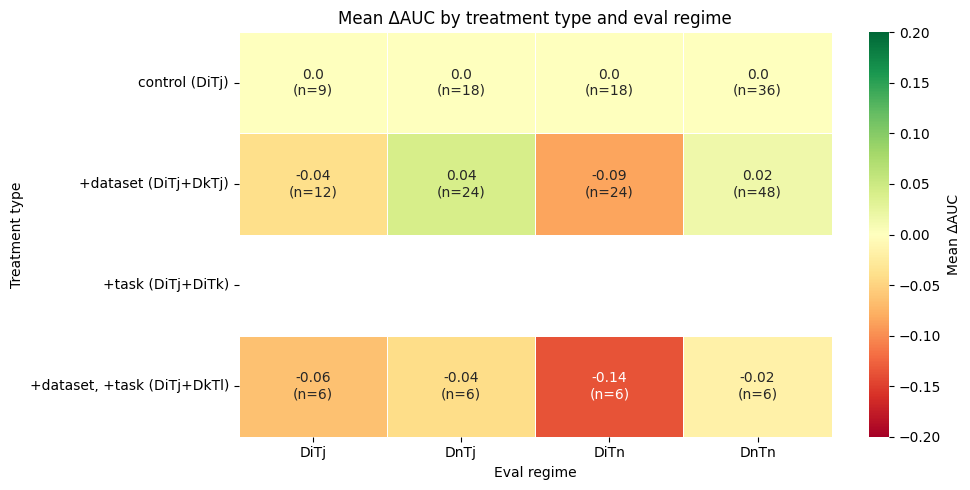

In [110]:


# ---- key change: aggregate mean + count ----
agg = (
    long
    .groupby(["treatment_type", "eval_regime"])["delta"]
    .agg(["mean", "count"])
)

# reshape
mean_table = agg["mean"].unstack("eval_regime")
count_table = agg["count"].unstack("eval_regime")

# enforce ordering
index_order = [
    "control (DiTj)",
    "+dataset (DiTj+DkTj)",
    "+task (DiTj+DiTk)",
    "+dataset, +task (DiTj+DkTl)",
]
col_order = ["DiTj", "DnTj", "DiTn", "DnTn"]

mean_table = mean_table.reindex(index=index_order, columns=col_order)
count_table = count_table.reindex(index=index_order, columns=col_order)

# ---- combine into single display ----
table = mean_table.round(2).astype(str) + " (n=" + count_table.astype(str) + ")"

display(table)

import matplotlib.pyplot as plt
import seaborn as sns

# numeric values for heatmap colors
hm = mean_table.astype(float)

# text labels
annot = mean_table.round(2).astype(str) + "\n(n=" + count_table.astype("Int64").astype(str) + ")"

plt.figure(figsize=(10, 5))
ax = sns.heatmap(
    hm,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    center=0,
    vmin=-0.2,
    vmax=0.2,
    linewidths=0.5,
    cbar_kws={"label": "Mean ΔAUC"},
)

ax.set_title("Mean ΔAUC by treatment type and eval regime")
ax.set_xlabel("Eval regime")
ax.set_ylabel("Treatment type")

plt.tight_layout()
plt.show()

eval_regime,DiTj,DnTj,DiTn,DnTn
treatment_type,,,,
control (DiTj),0.0 (n=9.0),0.0 (n=18.0),0.0 (n=18.0),0.0 (n=36.0)
+dataset (DiTj>DkTj),-0.07 (n=6.0),0.09 (n=12.0),-0.12 (n=12.0),0.04 (n=24.0)
+dataset (DkTj>DiTj),-0.01 (n=6.0),-0.0 (n=12.0),-0.05 (n=12.0),-0.0 (n=24.0)
+task (DiTj>DiTk),NaN,NaN,NaN,NaN
+task (DiTk>DiTj),NaN,NaN,NaN,NaN
"+dataset, +task (DiTj>DkTl)",-0.11 (n=3.0),-0.09 (n=3.0),-0.26 (n=3.0),-0.07 (n=3.0)
"+dataset, +task (DkTl>DiTj)",-0.02 (n=3.0),0.0 (n=3.0),-0.01 (n=3.0),0.04 (n=3.0)


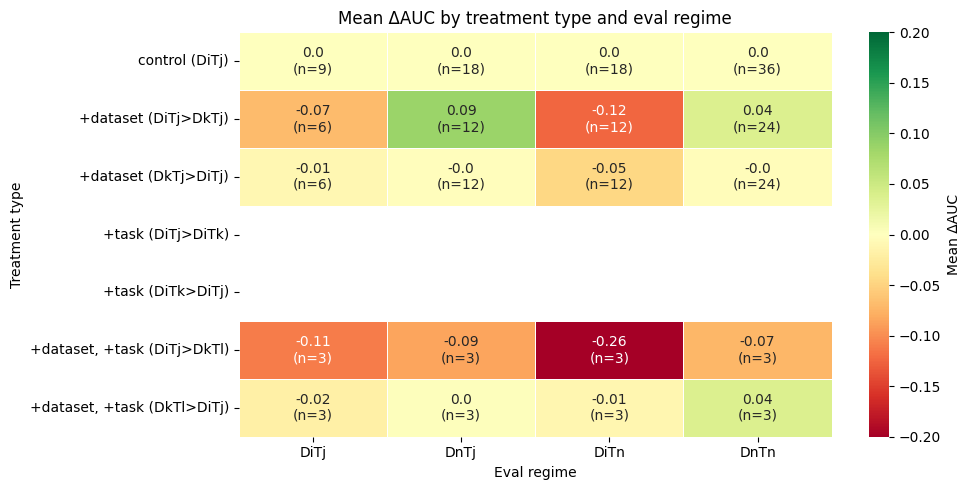

In [57]:
rows = []
for Di in datasets:
    for Tj in tasks:
        DiTj = f"{Di}+{Tj}"
        for Dn in datasets:
            for Tn in tasks:
                Y = f"{Dn}+{Tn}"
                eval_regime = regime(Di, Tj, Dn, Tn)

                control_id = f"{DiTj}|{Y}"
                control_auc = seq_auc(control_id)
                if control_auc is None:
                    continue

                rows.append({
                    "treatment_type": "control (DiTj)",
                    "eval_regime": eval_regime,
                    "control_id": control_id,
                    "treatment_id": control_id,
                    "control_auc": control_auc,
                    "treatment_auc": control_auc,
                    "delta": 0.0,
                })

                # +dataset, split by order
                for Dk in datasets:
                    if Dk == Di:
                        continue
                    DkTj = f"{Dk}+{Tj}"
                    for tid, ttype in [
                        (f"{DiTj}>{DkTj}|{Y}", "+dataset (DiTj>DkTj)"),
                        (f"{DkTj}>{DiTj}|{Y}", "+dataset (DkTj>DiTj)"),
                    ]:
                        auc = seq_auc(tid)
                        if auc is not None:
                            rows.append({
                                "treatment_type": ttype,
                                "eval_regime": eval_regime,
                                "control_id": control_id,
                                "treatment_id": tid,
                                "control_auc": control_auc,
                                "treatment_auc": auc,
                                "delta": auc - control_auc,
                            })

                # +task, split by order
                for Tk in tasks:
                    if Tk == Tj:
                        continue
                    DiTk = f"{Di}+{Tk}"
                    for tid, ttype in [
                        (f"{DiTj}>{DiTk}|{Y}", "+task (DiTj>DiTk)"),
                        (f"{DiTk}>{DiTj}|{Y}", "+task (DiTk>DiTj)"),
                    ]:
                        auc = seq_auc(tid)
                        if auc is not None:
                            rows.append({
                                "treatment_type": ttype,
                                "eval_regime": eval_regime,
                                "control_id": control_id,
                                "treatment_id": tid,
                                "control_auc": control_auc,
                                "treatment_auc": auc,
                                "delta": auc - control_auc,
                            })

                # +dataset, +task, split by order
                for Dk in datasets:
                    if Dk in (Di, Dn):
                        continue
                    for Tl in tasks:
                        if Tl in (Tj, Tn):
                            continue
                        DkTl = f"{Dk}+{Tl}"
                        for tid, ttype in [
                            (f"{DiTj}>{DkTl}|{Y}", "+dataset, +task (DiTj>DkTl)"),
                            (f"{DkTl}>{DiTj}|{Y}", "+dataset, +task (DkTl>DiTj)"),
                        ]:
                            auc = seq_auc(tid)
                            if auc is not None:
                                rows.append({
                                    "treatment_type": ttype,
                                    "eval_regime": eval_regime,
                                    "control_id": control_id,
                                    "treatment_id": tid,
                                    "control_auc": control_auc,
                                    "treatment_auc": auc,
                                    "delta": auc - control_auc,
                                })


long = pd.DataFrame(rows)

agg = (
    long
    .groupby(["treatment_type", "eval_regime"])["delta"]
    .agg(["mean", "count"])
)

mean_table = agg["mean"].unstack("eval_regime")
count_table = agg["count"].unstack("eval_regime")

index_order = [
    "control (DiTj)",
    "+dataset (DiTj>DkTj)",
    "+dataset (DkTj>DiTj)",
    "+task (DiTj>DiTk)",
    "+task (DiTk>DiTj)",
    "+dataset, +task (DiTj>DkTl)",
    "+dataset, +task (DkTl>DiTj)",
]
col_order = ["DiTj", "DnTj", "DiTn", "DnTn"]

mean_table = mean_table.reindex(index=index_order, columns=col_order)
count_table = count_table.reindex(index=index_order, columns=col_order)

table = mean_table.round(2).astype(str) + " (n=" + count_table.astype(str) + ")"

display(table)

import matplotlib.pyplot as plt
import seaborn as sns

# numeric values for heatmap colors
hm = mean_table.astype(float)

# text labels
annot = mean_table.round(2).astype(str) + "\n(n=" + count_table.astype("Int64").astype(str) + ")"

plt.figure(figsize=(10, 5))
ax = sns.heatmap(
    hm,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    center=0,
    vmin=-0.2,
    vmax=0.2,
    linewidths=0.5,
    cbar_kws={"label": "Mean ΔAUC"},
)

ax.set_title("Mean ΔAUC by treatment type and eval regime")
ax.set_xlabel("Eval regime")
ax.set_ylabel("Treatment type")

plt.tight_layout()
plt.show()

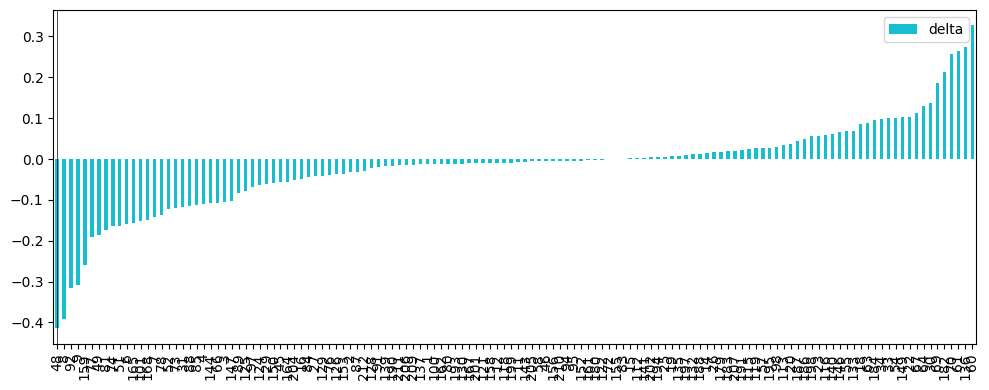

In [58]:
import matplotlib.pyplot as plt

sub = long[long.treatment_type.ne('control (DiTj)')].sort_values('delta')

types = sub.treatment_type.unique()
cmap = plt.get_cmap('tab10')
# color_map = {
#     '+dataset (DiTj>DkTj)': 'green',
#     '+dataset (DkTj>DiTj)': 'green',
#     '+dataset, +task (DiTj>DkTl)': "blue",
#     '+dataset, +task (DkTl>DiTj)': "blue"
# }
# order = [
#     "+dataset (DiTj>DkTj)", "+dataset (DkTj>DiTj)",
#     "+task (DiTj>DiTk)", "+task (DiTk>DiTj)",
#     "+dataset, +task (DiTj>DkTl)", "+dataset, +task (DkTl>DiTj)",
# ]
color_map = {t: cmap(i) for i, t in enumerate(sub.treatment_type)}
colors = sub.treatment_type.map(color_map)

ax = sub.delta.plot.bar(color=colors, figsize=(10, 4))

# legend
handles = [plt.Rectangle((0,0), 1, 1) for t in types]
ax.legend()
ax.axvline(0, color='k', lw=0.5)
plt.tight_layout()

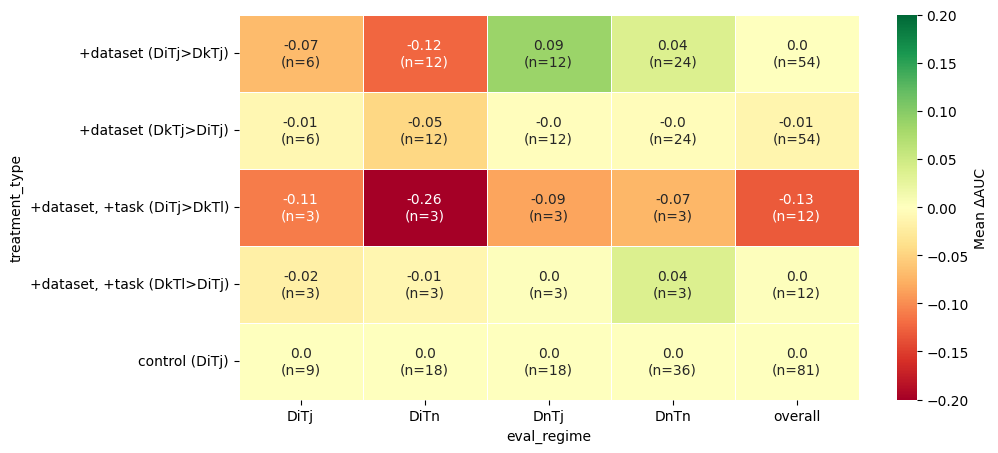

In [ ]:
agg = (
    long
    .groupby(["treatment_type", "eval_regime"])["delta"]
    .agg(["mean", "count"])
)

mean_table = agg["mean"].unstack("eval_regime")
count_table = agg["count"].unstack("eval_regime")

# overall (across all eval regimes)
overall = long.groupby("treatment_type")["delta"].agg(["mean", "count"])
mean_table["overall"] = overall["mean"]
count_table["overall"] = overall["count"]

index_order = [
    "control (DiTj)",
    "+dataset (DiTj>DkTj)",
    "+dataset (DkTj>DiTj)",
    "+task (DiTj>DiTk)",
    "+task (DiTk>DiTj)",
    "+dataset, +task (DiTj>DkTl)",
    "+dataset, +task (DkTl>DiTj)",
]
col_order = ["DiTj", "DnTj", "DiTn", "DnTn", "overall"]

# mean_table = mean_table.reindex(index=index_order, columns=col_order)
# count_table = count_table.reindex(index=index_order, columns=col_order)

table = mean_table.round(4).astype(str) + " (n=" + count_table.astype(str) + ")"

# plot matrix
plt.figure(figsize=(10, 5))
hm = mean_table.astype(float)
annot = mean_table.round(2).astype(str) + "\n(n=" + count_table.astype("Int64").astype(str) + ")"
ax = sns.heatmap(
    hm,
    annot=annot,
    fmt="",
    cmap="RdYlGn",
    center=0,
    vmin=-0.2,
    vmax=0.2,
    linewidths=0.5,
    cbar_kws={"label": "Mean ΔAUC"},
)   